**Coursebook: Time Series and Forecasting**

- Part of Data Science in Python Specialization for PT Freeport Indonesia
- Course Length: 9 Hours
- Last Updated: September 2025

---

- Developed by [Algoritma](https://algorit.ma/)'s product division and instructors team

## Background 

 The coursebook is part of the **Comprehensive Data Science and Machine Learning Program** prepared by Algoritma. The coursebook is intended for a restricted audience only, i.e. the individuals and organizations having received this coursebook directly from the training organization. It may not be reproduced, distributed, translated or adapted in any form outside these individuals and organizations without permission.
 
 Algoritma is a data science education center based in Jakarta. We organize workshops and training programs to help working professionals and students gain mastery in various data science sub-fields: data visualization, machine learning, data modeling, statistical inference etc.

## Training Objectives

This coursebook is intended for participants who have completed the preceding courses. 

In this coursebook we will cover:

- **Data Preparation** 
    - Data types inspection 
    - Data sorting
    - Missing Value Checking 
    - Feature Selection
- **Exploratory Data Analysis**
    - Time series frequency
    - Data aggregation
    - General Additive Model (GAM)
        - Decomposition of Time Series Data
    - Extracting trend and seasonality
- **Data Pre-Processing**
    - Cross Validation for Time Series Data
        - Train-Test Split
- **Model Time Series (`prophet`)**
    - Baseline Model Preparation
    - Baseline Model Adjustment
        - Trend Adjustment
        - Seasonality Adjustment
            - Fourier order for seasonality component
            - Modeling holidays and special events
            - Built-in country holidays
    - Hyperparameter Tuning
- **Model Performance & Model Implementation**
    - Evaluation metrics
        - Error
    - Model Forecasting

---

Before going into our main topic for this coursebook, let's import the packages we are going to use:

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# suppress scientific notation
np.set_printoptions(suppress=True) # numpy output
pd.set_option('display.float_format', lambda x: '%.2f' % x) # pandas output
pd.options.display.float_format = '{:,.2f}'.format 

# suppress warning
import warnings
warnings.filterwarnings("ignore")

%matplotlib inline

## Introduction to Time Series and Forecasting


### Regression vs Forecasting

The fundamental difference between time series and regression is that, in regression, to predict a value of `Y`, it is influenced by several factors such as `x1, x2,.., xn`. On the other hand, in time series, to predict a value of `Y`, it is influenced by its own past value ($Y_{t-1}$).

*Regression*

$$y = \beta_0+\beta_1*x_1+\beta_2*x_2+...+\beta_n*x_n$$

*Time Series*

$$y_t = \beta_0+\beta_1*y_{t-1}+\beta_2*y_{t-2}+...+\beta_n*y_{t-n}$$

The first equation represents a linear regression model, where the value of the dependent variable y is predicted based on the values of one or more independent variables `x1, x2, ..., xn`. This model assumes that there is a linear relationship between the dependent variable and the independent variables, and the regression coefficients (*β0, β1, β2, ..., βn*) are estimated to determine the strength and direction of the relationship.

On the other hand, the second equation represents a time series model, specifically an autoregressive model. Here, the value of the dependent variable at time `t (yt)` is predicted based on its previous values at times `t-1, t-2, ..., t-n`. This model assumes that the value of the dependent variable is dependent on its past values and any external factors that may affect it.

The main difference between regression and time series models is:
>  that regression models are used to predict the value of the dependent variable based on the values of one or more independent variables, while time series models are used to predict the future values of a dependent variable based on its past values. 

Time series models are particularly useful for analyzing and forecasting data that has a temporal component, such as stock prices, weather patterns, or daily sales data.

Regression is used to find the relationship between two or more variables, where one variable is considered dependent (or response) and the others are considered independent (or predictor). We use Regression to predict the value of the dependent variable based on the values of the independent variables. For example, you might use regression to determine the relationship between a person's age and their income.

Forecasting, on the other hand, is the process of predicting future values based on historical data. It is a technique used to predict future trends and patterns based on historical data. Forecasting can be used for many purposes, such as predicting future sales or stock prices. 

While regression can be used for forecasting purposes, it is not specifically designed for tasks where it includes time and trend. Regression is used to determine the relationship between variables, while forecasting is used to predict future values based on historical data. We call such historical data as Time Series. 



### Time Series

Time series data is one of the most common form of data to be found in every industry. It is considered to be a significant area of interest for most industries: retail, telecommunication, logistic, engineering, finance, and socio-economic. Time series analysis aims to extract the underlying components of a time series to better understand the nature of the data. Above, it was showed that time series can be applied to sales analysis. But time series applications isn't limited only to it - common application areas of time series include:

- **finance** : Technical trading strategies using daily share price fluctuation, or tracing the fluctuation of a current daily exchange rate, etc.
- **marketing** : Predicting global demand for a beverage using aggregated monthly sales data
- **economics** : Monthly statistics on unemployment, personal income tax, gov’t expenditure records
- **socio-environmental** : Periodic records on hospital admissions, rainfall, air quality readings, seasonal influenza-associated deaths, energy demand forecasting
- **science** : ECG brain wave activity every $2^{−8}$ (0.004) seconds

But on this series we will focus on its application in oil and gas prediction. 

# Study Case: Prediction of Pressure on Tubing Pressure Transducer in Offshore Oil Well Production

**Petrobras** is Brazil's national oil and gas company founded in 1953. As one of the world's largest energy companies, Petrobras operates in oil and gas exploration, production, refining, and distribution. Known for its technological innovations, especially in deepwater drilling, the company has significant oil reserves and contributes greatly to the Brazilian economy.

Petrobras has released a comprehensive dataset for analytical and educational purposes. This dataset records data from a subsea Christmas tree installed on the seabed, which is composed of valves and sensors operated remotely through an electro-hydraulic umbilical. The dataset includes pressure and temperature measurements with details such as timestamp, P-PDG, P-TPT, T-TPT, P-MON-CKP, T-JUS-CKP, P-JUS-CKGL, T-JUS-CKGL, QGL, and operational condition classification. Each file contains per-second monitoring results from the subsea Christmas tree on the seafloor for 5 hours, and is available at this link https://data.mendeley.com/datasets/r7774rwc7v/1 .

For this course, the data has been preprocessed and aggregated into hourly records.

The most commonly monitored variables in Petrobras offshore operations include:

- Pressure at the PDG
- Pressure at the TPT
- Temperature at the TPT
- Pressure upstream of the PCK
- Temperature downstream of the PCK

Using the Petrobras dataset, we aim to predict the pressure at the tubing pressure transducer (P-TPT) to identify potential problems early and take necessary precautions.


## Import Data

First, let's read our Petrobas oil Production data from the `hourly-petrobas.csv` in the `data_input` folder.

In [2]:
petro = pd.read_csv('data_input/hourly-petrobas.csv')
petro.head()

,P-PDG,P-TPT,T-TPT,P-MON-CKP,T-JUS-CKP,P-JUS-CKGL,T-JUS-CKGL,QGL,class,timestamp
0,0.00,"14,221,467.86",116.74,"6,142,448.04",69.57,"3,123,129.69",NaN,0.00,0.00,2017-05-22 01:00:00
1,0.00,"14,233,137.36",116.76,"6,141,768.72",69.43,"3,121,500.43",NaN,0.00,0.00,2017-05-22 02:00:00
2,0.00,"14,223,380.27",116.72,"6,152,984.41",69.44,"3,119,871.17",NaN,0.00,0.00,2017-05-22 03:00:00
3,0.00,"14,218,446.47",116.71,"6,140,252.16",69.37,"3,118,241.90",NaN,0.00,0.00,2017-05-22 04:00:00
4,0.00,"14,213,509.25",116.71,"6,144,555.97",69.32,"3,116,682.05",NaN,0.00,0.00,2017-05-22 05:00:00


Here is an explanation of each column from the Petrobas dataset:

- **timestamp**: The date and time when the data was recorded hourly.
- **P-PDG**: Pressure at the PDG (Pressure Downhole Gauge) measurement point, in Pascal [Pa].
- **P-TPT**: Pressure at the tubing pressure transducer, in Pascal [Pa].
- **T-TPT**: Temperature at the tubing pressure transducer, in degrees Celsius.
- **P-MON-CKP**: Pressure at the monitoring checkpoint,  in Pascal [Pa].
- **T-JUS-CKP**: Temperature at the just casing pressure checkpoint, in degrees Celsius.
- **P-JUS-CKGL**: Pressure at the just casing gauge location, in Pascal [Pa].
- **T-JUS-CKGL**: Temperature at just casing gauge location, in degrees Celsius.
- **QGL**: Gas lift quantity, standard cubic meters per second [sm3/s].
- **class**: Classification problems that diagnose by Abnormal Event Management (AEM)
    + 0 : NORMAL
    + 1 : ABRUPT INCREASE OF BSW	
    + 2 : SPURIOUS CLOSURE OF DHSV
    + 3 : SEVERE SLUGGING
    + 4 : FLOW INSTABILITY
    + 5 : RAPID PRODUCTIVITY LOSS	
    + 6 : QUICK RESTRICTION IN PCK
    + 7 : SCALING IN PCK
    + 8 : HYDRATE IN PRODUCTION LINE

## Data Preparation

Data preparation is the initial step after we formulate the right business question. The main objective of this process is to ensure data suitability. That is, we aim to work with data in the correct format. Time series data is defined as data observations that are collected at regular time intervals. In this case, we are talking about christmas tree monitoring on oil production that recorded hourly interval for each observation

We have to make sure our data is ready to be fitted into models, such as:

- Convert `date` column data type from `object` to `datetime64`
- Sort the data ascending by `date` column
- Feature engineering of column which will be forecasted


### Data Types Inspection

When we call `pd.read_csv()` earlier, `pandas` will try to infer data types from the values in each column. Sometimes, it get it right but more often that not, a data analyst's intervention is required. In the following sub-section, we'll learn about various techniques an analyst have at his/her disposal when it comes to the treatment of pandas data types.

In [19]:
# check the data types
petro.dtypes

P-PDG         float64
P-TPT         float64
T-TPT         float64
P-MON-CKP     float64
T-JUS-CKP     float64
P-JUS-CKGL    float64
T-JUS-CKGL    float64
QGL           float64
class         float64
timestamp      object
dtype: object

The result above perform an information about data types in every columns from `petros` DataFrame. Based on business knowledge, we know that `timestamp` and `class` variable not in the right data types. This process is known as **implicit coercion** where date values are forced into one type of class based on the most general value existing. So, we need to transform `timestamp` variables into `datetime64` data types and `class` to `category`

In [20]:
# to date time
from datetime import datetime
petro['timestamp']=pd.to_datetime(petro['timestamp'], format='ISO8601')

# to category
petro['class']= petro['class'].astype('category')

# recheck the data types
petro.dtypes

P-PDG                float64
P-TPT                float64
T-TPT                float64
P-MON-CKP            float64
T-JUS-CKP            float64
P-JUS-CKGL           float64
T-JUS-CKGL           float64
QGL                  float64
class               category
timestamp     datetime64[ns]
dtype: object

### Sorting The Data

One of the requirements in creating a Time Series model is that the date data must be sorted properly from the **past** data to the **current** data.

To sort the data, we can use the method `.sort_values()`

In [21]:
# Sorting Values
petro.sort_values('timestamp', inplace=True)

print("minimum_date", petro['timestamp'].head(1))
print("maximum_date", petro['timestamp'].tail(1))

minimum_date 0   2017-05-22 01:00:00
Name: timestamp, dtype: datetime64[ns]
maximum_date 169   2017-05-29 02:00:00
Name: timestamp, dtype: datetime64[ns]


According to the time range check above, we can know that this petrobas data starts from `2017-05-22 01:00:00` to `2017-05-29 02:00:00`.

### Missing Value Checking

Before further analysis is carried out, we need to check whether our data has no missing values, this is so that when analyzing time series, a complete pattern can be obtained for forecasting.

In [22]:
# Missing Values Checking
petro.isnull().sum()

P-PDG           0
P-TPT           0
T-TPT           0
P-MON-CKP       0
T-JUS-CKP       0
P-JUS-CKGL      0
T-JUS-CKGL    170
QGL             0
class           0
timestamp       0
dtype: int64

In [23]:
# values checking
petro.nunique()

P-PDG           1
P-TPT         170
T-TPT         165
P-MON-CKP     170
T-JUS-CKP     170
P-JUS-CKGL    170
T-JUS-CKGL      0
QGL             1
class           1
timestamp     170
dtype: int64

After checking the missing value and values checking for each column, we can find out that :

- the `T-JUS-CKGL` column has the most missing values. 
- the `P-PDG`, `QGL` and `class` columns only have 1 values.

so we will not include it in the next stage. 

In [24]:
# Drop columns that are not needed
petro.drop(columns=["P-PDG","T-JUS-CKGL","QGL","class"],inplace=True)

### Exploratory Data Analysis

Exploratory Data Analysis (EDA) is a crucial initial stage for understanding the characteristics of dataset. EDA helps data scientists identify patterns, trends, anomalies and relationships between variables, and select relevant features.

**Statistics Summary**

Now that the data type have been corrected, we can see more detailed information in our data. The first thing we will review is the statistical description of our data. To see descriptions of each columns in the dataset, we can use the `.describe()` method.

In [25]:
petro.describe()

,P-TPT,T-TPT,P-MON-CKP,T-JUS-CKP,P-JUS-CKGL,timestamp
count,170.00,170.00,170.00,170.00,170.00,170
mean,"14,212,463.34",116.72,"6,115,022.93",69.18,"3,048,973.15",2017-05-25 13:29:59.999999744
min,"14,078,882.84",116.56,"6,033,413.30",68.62,"3,001,506.03",2017-05-22 01:00:00
25%,"14,200,369.46",116.67,"6,096,305.14",69.05,"3,017,375.03",2017-05-23 19:15:00
50%,"14,213,429.63",116.74,"6,115,820.95",69.20,"3,045,108.89",2017-05-25 13:30:00
75%,"14,227,928.07",116.77,"6,135,844.04",69.34,"3,075,186.08",2017-05-27 07:45:00
max,"14,300,578.09",116.87,"6,195,643.37",69.59,"3,123,129.69",2017-05-29 02:00:00
std,"23,724.33",0.07,"25,048.21",0.21,"33,707.47",NaN


Based on the results of the data description above we can get information that:

- the pressure on the TPT is in the range of 14.2 - 14.3 million pascals with a standard deviation of 23.724 pascals. This indicates that the pressure recorded per second on the TPT is quite consistent, so we can state that the pressure on the TPT tends to stable.
- The temperature on the TPT is in the range of 116.56 - 116.87 degrees Celsius with a standard deviation of 0.11 degrees Celsius, so we can state that the temperature on the TPT tends to be stable with changes that are not too significant.
- The pressure at MON-CKP is in the range of 6 - 6.19 million pascals with a standard deviation of 25.048 pascals. This indicates that the pressure recorded at MON-CKP is quite consistent, so we can say that the pressure at MON-CKP tends to stable.
- The temperature on the JUS-CKP is in the range of 68 - 69.6 degrees Celsius with a standard deviation of 0.21 degrees Celsius, so we can state that the temperature on the JUS-CKP tends to be stable with changes that are not too significant.
- The pressure at JUS-CKGL is in the range of 3 - 3.12 million pascals with a standard deviation of 33.707 pascals. This indicates that the pressure recorded at JUS-CKGL is quite consistent, so we can say that the pressure at JUS-CKGL tends to be stable.

### Visualization: Multiple vs Multivariate Time Series

One of an important aspect in time series analysis is performing a visual exploratory analysis. Python is known for its graphical capabilities and has a very popular visualization package called **`matplotlib` and `seaborn`**. Let’s take our `daily_sales` data frame we have created earlier and observe through the visualization.

⚠️ There is a misconception between multiple and multivariate time series. Here are the definitions for each term:

- Multiple time series: There is **one variable** from **multiple objects** being observed from time to time.

- Multivariate Time series: There are **multiple variables** from only **one object** being observed from time to time. Typically for such series, the variables are closely interrelated.


### Multiple Time Series

Because our data contains only one observation, well 00001, we cannot create visualizations for multiple time series. Here is an example of visualization for multiple time series that show  the `total_qty` fluctuation of the top 3 shops, namely `shop_id` 25, 31, and 54.
![multiplets.png](assets/multiplets.png)


Based on the multiple time series visualization of the top 3 shops, namely `shop_id` 25, 31, and 54 above, we can observe that the `total_qty` fluctuation is significantly different for each shop. Specifically, `shop_id` 25 and 31 experience extreme spikes at the end of each year, while `shop_id` 54 does not have any significant spikes. We chose to focus on `shop_id` 31 due to its high potential for improvement in terms of sales performance.

### Multivariate Time Series

In our case, multivariate time series is when we observed the pressure of `P-TPT` and `P-MON-CKP` over time, from only `Well 00001`.

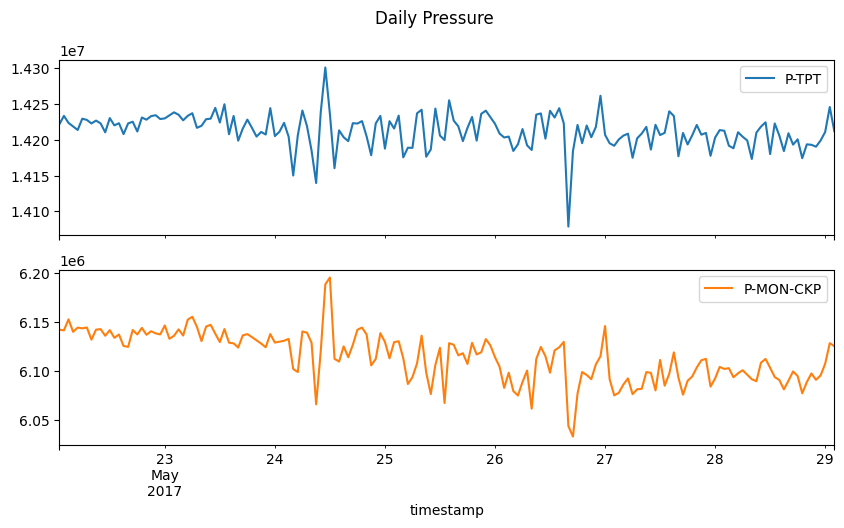

In [26]:
import matplotlib.pyplot as plt

# pressure data visualization
petro.set_index('timestamp')[['P-TPT','P-MON-CKP']].plot(subplots=True,figsize=(10, 5))
plt.suptitle('Daily Pressure')
plt.show()

From the visualization we can conclude that the fluctuations of `P-TPT` and `P-MON-CKP` look similar distributed across time.

## Modeling using `prophet`

Time series forecasting is an essential component of data analysis, and it has become more critical in recent years as businesses rely on data to make informed decisions. The ability to predict future trends is essential for various industries, including finance, healthcare, and e-commerce. However, analyzing time series data can be challenging, as it involves decomposing the underlying components into trend, seasonality, and residuals.

The ability to predict future trends and patterns is crucial in many business domains, particularly in retail. Accurate sales forecasting allows retailers to optimize inventory levels, improve pricing strategies, and ultimately increase revenue. However, sales forecasting can be challenging due to the complex and dynamic nature of consumer behavior.

One of the recent advancements in time series forecasting is the **General Additive Model (GAM)**, which describes time series as a summation of its components. The three primary components of GAM are trend, seasonality, and residuals, which help to model the patterns and irregularities of the time series. As a starter, we will define time series with 3 different components:

- Trend ($T$): Long term movement in its mean
- Seasonality ($S$): Repeated seasonal effects
- Residuals ($E$): Irregular components or random fluctuations not described by trend and seasonality

The idea of GAM is that each of them is added to describe our time series:

$Y(t) = T(t) + S(t) + E(t)$

**Facebook** developed Prophet, an open-source tool that leverages GAM to make time series forecasting more accessible to non-experts. Prophet builds upon the traditional trend and seasonality components and adds a holiday effect to model irregular schedules, such as holidays. 

**Prophet**'s straightforward approach allows users to input their data and generate forecasts with minimal coding knowledge. It also includes robust model diagnostics and visualization tools, making it easy to identify issues and adjust the model as necessary.

**Prophet** has been proven to be useful in various industries, including retail, finance, and transportation. The tool's ability to model the irregular schedules of holidays and other events has made it a popular choice for businesses that rely on accurate forecasting to make decisions. Additionally, Prophet's flexibility and ease of use make it an attractive option for businesses of all sizes, from small startups to large corporations.

In conclusion, Prophet is an innovative tool that leverages GAM to make time series forecasting more accessible and user-friendly. Its ability to model trend, seasonality, and holiday effects has made it a popular choice among businesses that require accurate forecasting to make informed decisions.

To get started with Prophet, users can refer to the [official documentation](https://facebook.github.io/prophet/docs/quick_start.html) provided by Facebook. The documentation provides a comprehensive guide on how to install and use Prophet, including examples and best practices for time series forecasting. The documentation also includes information on how to fine-tune the model parameters and how to incorporate external regressors, such as holiday effects or other time series data, into the forecasting model. Users can access the documentation online or download it as a PDF file.

## Prepare the data

To use the `prophet` package, we first need to prepare our time series data into a specific format data frame required by the package. The data frame requires 2 columns:

- `ds`: the time stamp column, stored in `datetime64` data type
- `y`: the value to be forecasted

In this example, we will be using the `P-TPT` as the value to be forecasted.

In [27]:
# only retrieves P-TPT and timestamp columns
p_tpt = petro[['timestamp', 'P-TPT']]

# rename columns to ds & y
p_tpt = p_tpt.rename(
    columns = {'timestamp' : 'ds',
               'P-TPT' : 'y'})

p_tpt.head()

,ds,y
0,2017-05-22 01:00:00,"14,221,467.86"
1,2017-05-22 02:00:00,"14,233,137.36"
2,2017-05-22 03:00:00,"14,223,380.27"
3,2017-05-22 04:00:00,"14,218,446.47"
4,2017-05-22 05:00:00,"14,213,509.25"


The data (`p_tpt`) represents the daily records of a pressure at the tubing pressure transducer from  `2017-05-22 01:00:00` to `2017-05-29 02:00:00`. Each row in the table represents average pressure in a hour, with the date of the pressure recorded in the first column. The second column shows the measure of pressure (changed into `y`) of on that time. For example, on May 22nd, 2017, on 01:00:00 the average tubing pressure transducer is 14,221,467.86 pascals. The data is organized in a tabular format, with each row representing a different second and the pressure data for that time in the corresponding columns.

The format of data as shown in the example (date/time and a corresponding value) is a standard format for time series analysis and forecasting. This format is necessary because time series data has a temporal dimension, which means that each data point is associated with a specific date/time. In order to capture the underlying patterns and trends in the data, it is important to maintain the temporal information.

**Additionally**, most time series analysis and forecasting methods require the data to be in a specific format. For example, Prophet, a popular time series forecasting tool, requires the data to be in a dataframe with two columns: 

- `ds` (date or datetime) and 
- `y` (numeric value)

Therefore, it is important to have time series data in a format that is compatible with the analysis and forecasting tools being used, and the standard format of date/time and corresponding value is a widely accepted and compatible format. With our data in this format, we can proceed to the next step of the analysis which is fitting the data to a model.

### Cross Validation

As in the case of classification/regression where evaluation is done to find out how well the model that has been built performs. In time series models, there is also a model evaluation stage where we will split our data into **train data** and **test data**.

💬 Evaluation of forecasting models with splitting method involves dividing the data into two parts:

- **Train Data**: Used to train the time series model to identify basic patterns such as trends and seasonality.
- **Test Data**: serves as **unseen data** to see how the model performs.

The CV concept for TS models will be the same as classification models and regression models, where *the train data will be more than the test data*. However, there is one other criterion that must be met, namely:

- Train data will use initial data 
- Test data will use the final data

Let's look at our range data again

In [28]:
p_tpt['ds'].describe()

count                              170
mean     2017-05-25 13:29:59.999999744
min                2017-05-22 01:00:00
25%                2017-05-23 19:15:00
50%                2017-05-25 13:30:00
75%                2017-05-27 07:45:00
max                2017-05-29 02:00:00
Name: ds, dtype: object

To model time series, the data we have should have at least two repetitions of the seasonal pattern. This is important so that the model can predict new data more accurately based on the seasonal pattern. In our data, we will observe a daily seasonal pattern, so we need a minimum of 2 days of data.

In our data it can be seen that there are start from 22 May until 29 May 2017. and 75% of the data is on May 27th, 2017. therefore we will divide the data we have to be used as training data is 75% of the data and the remaining 25% we will use as test data. 

- data train : date <= 2017-05-27
- data test : date > 2017-05-27

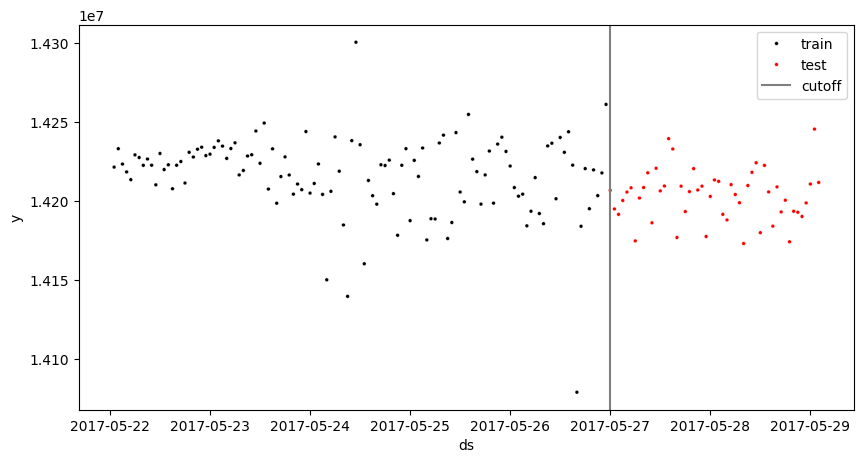

In [29]:
# for illustration purposes only
cutoff = pd.to_datetime('2017-05-27')
p_tpt['type'] = p_tpt['ds'].apply(
    lambda date: 'train' if date < cutoff else 'test')

plt.figure(figsize=(10, 5))
sns.scatterplot(x='ds', y='y', hue='type', s=7,
                palette=['black', 'red'],
                data=p_tpt)
plt.axvline(x=cutoff, color='gray', label='cutoff')
plt.legend()
plt.show()

We can split at a cutoff using conditional subsetting as below:

In [30]:
train = p_tpt[p_tpt['ds'] <= '2017-05-27']
test = p_tpt[(p_tpt['ds'] > '2017-05-27')]

print(f'Train size: {train.shape}')
print(f'Test size: {test.shape}')

Train size: (120, 3)
Test size: (50, 3)


## Fitting Model 

The fitting model step involves training the forecasting model on the historical data. In this case, we will use the Prophet library in Python to fit the time series data. 

First, we will initiate a `prophet` object using `Prophet()` and add our time series data (`p_tpt`) to it. Then, we will call the `.fit()` method on the object to fit the model on the historical data. During the fitting process, the Prophet model will identify the trends, seasonality, and any other patterns in the data. 

In [31]:
# load the library
# %pip install prophet

from prophet import Prophet
import cmdstanpy

Importing plotly failed. Interactive plots will not work.


In [32]:
# build base model
model_base = Prophet()

# train model 
model_base.fit(train)

17:20:33 - cmdstanpy - INFO - Chain [1] start processing
17:20:34 - cmdstanpy - INFO - Chain [1] done processing


The code is fitting the time series data stored in the `train` DataFrame to a Prophet model object named `model_base`. The Prophet model is initialized without any arguments, so it uses the default settings. The `fit` method is then called on the model object with the time series data as its argument to train the model on the historical data. After fitting the model, the resulting trained model is stored in `model_base`. This trained model can then be used to make predictions for future time periods.

### Forecasting

Based on the existing data, we'd like to perform a forecasting for **50 hours**. To do that, we will need to first prepare a data frame that consist of the future time stamp range we'd like to forecast. Luckily, `prophet` has provided `.make_future_dataframe()` method that help us to prepare the data:

In [33]:
future_base = model_base.make_future_dataframe(periods = 50, freq= 'h')
future_base.tail()

,ds
165,2017-05-28 22:00:00
166,2017-05-28 23:00:00
167,2017-05-29 00:00:00
168,2017-05-29 01:00:00
169,2017-05-29 02:00:00


Now we have acquired a new `future_base` data frame that consist of a date span of **the beginning of a time series to 50 hours into the future**. We will then use this data frame is to perform the forecasting by using `.predict()` method of our `model_base`:

In [35]:
forecast_base = model_base.predict(future_base)

Perform top 5 observation from `forecast_base`:

In [36]:
forecast_base.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,daily,daily_lower,daily_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2017-05-22 01:00:00,"14,227,716.65","14,204,202.78","14,262,262.29","14,227,716.65","14,227,716.65","6,324.71","6,324.71","6,324.71","6,324.71","6,324.71","6,324.71",0.00,0.00,0.00,"14,234,041.36"
1,2017-05-22 02:00:00,"14,227,133.48","14,194,866.47","14,251,972.63","14,227,133.48","14,227,133.48","-3,228.97","-3,228.97","-3,228.97","-3,228.97","-3,228.97","-3,228.97",0.00,0.00,0.00,"14,223,904.51"
2,2017-05-22 03:00:00,"14,226,550.32","14,187,868.94","14,244,444.99","14,226,550.32","14,226,550.32","-10,715.58","-10,715.58","-10,715.58","-10,715.58","-10,715.58","-10,715.58",0.00,0.00,0.00,"14,215,834.74"
3,2017-05-22 04:00:00,"14,225,967.16","14,187,240.82","14,242,476.47","14,225,967.16","14,225,967.16","-11,800.75","-11,800.75","-11,800.75","-11,800.75","-11,800.75","-11,800.75",0.00,0.00,0.00,"14,214,166.41"
4,2017-05-22 05:00:00,"14,225,383.99","14,189,560.44","14,244,826.60","14,225,383.99","14,225,383.99","-7,720.80","-7,720.80","-7,720.80","-7,720.80","-7,720.80","-7,720.80",0.00,0.00,0.00,"14,217,663.19"


The output will generate a DataFrame with the following columns:

- `ds`: the date values in the future that we have specified in the `p_tpt` DataFrame
- `yhat`: the forecasted values for the `y` column
- `yhat_lower`: the lower bound of the forecasted values
- `yhat_upper`: the upper bound of the forecasted values


- `trend`: the trend component of the forecasted values
- `trend_lower`: the lower bound of the trend
- `trend_upper`: the upper bound of the trend


- `daily`: the daily component of the forecasted values
- `daily_lower`: the lower bound of the daily component of the forecasted values
- `daily_upper`: the upper bound of the daily component of the forecasted values


- `additive_terms`: the additive component of the forecasted values
- `additive_terms_lower`: the lower bound of the additive component of the forecasted values
- `additive_terms_upper`: the upper bound of the additive component of the forecasted values

- `multiplicative_terms`: the multiplicative component of the forecasted values
- `multiplicative_terms_lower`: the lower bound of the multiplicative component of the forecasted values
- `multiplicative_terms_upper`: the upper bound of the multiplicative component of the forecasted values

Select several information from forecasting result:

In [38]:
forecast_base[['ds','daily', 'trend', 'yhat']].head()

,ds,daily,trend,yhat
0,2017-05-22 01:00:00,"6,324.71","14,227,716.65","14,234,041.36"
1,2017-05-22 02:00:00,"-3,228.97","14,227,133.48","14,223,904.51"
2,2017-05-22 03:00:00,"-10,715.58","14,226,550.32","14,215,834.74"
3,2017-05-22 04:00:00,"-11,800.75","14,225,967.16","14,214,166.41"
4,2017-05-22 05:00:00,"-7,720.80","14,225,383.99","14,217,663.19"


Recall that in General Additive Model, we use time series components and perform a summation of all components. In this case, we can see that the model is extracting only one types of components: `trend`. Means, in forecasting future values it will use the following formula:

$yhat(t) = T(t)+S_{daily}(t) $

We can manually confirm from `forecast_base` that the column `yhat` = `trend`+`daily`.


In [39]:
forecast_base['trend'] + forecast_base['daily']

0     14,234,041.36
1     14,223,904.51
2     14,215,834.74
3     14,214,166.41
4     14,217,663.19
           ...     
165   14,194,014.90
166   14,198,165.09
167   14,198,736.83
168   14,192,836.24
169   14,182,907.57
Length: 170, dtype: float64

In [40]:
forecast_base['yhat']

0     14,234,041.36
1     14,223,904.51
2     14,215,834.74
3     14,214,166.41
4     14,217,663.19
           ...     
165   14,194,014.90
166   14,198,165.09
167   14,198,736.83
168   14,192,836.24
169   14,182,907.57
Name: yhat, Length: 170, dtype: float64

### Visualize

Now, observe how `.plot()` method take our model_base, and newly created forecast_base object to create a `matplotlib` object that shows the forecasting result. The black points in the plot shows the **actual** time series, and the blue line shows the **fitted** time series along with its forecasted values 365 days into the future.

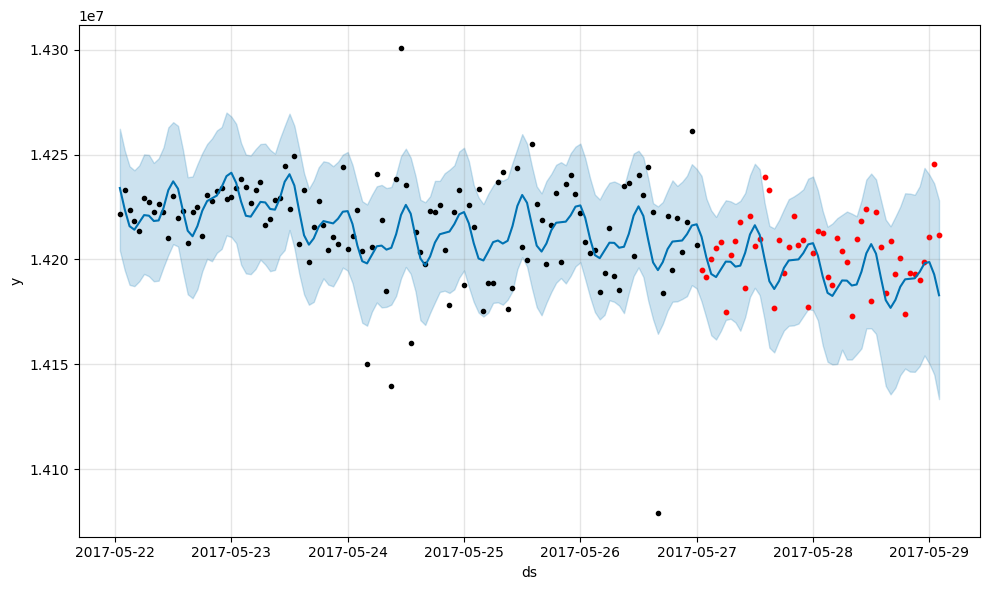

In [41]:
# visualize
fig = model_base.plot(forecast_base)
plt.scatter(x=test['ds'], y=test['y'], s=10, color='red')
plt.show()

We can also visualize each of the trend and seasonality components using `.plot_components` method.

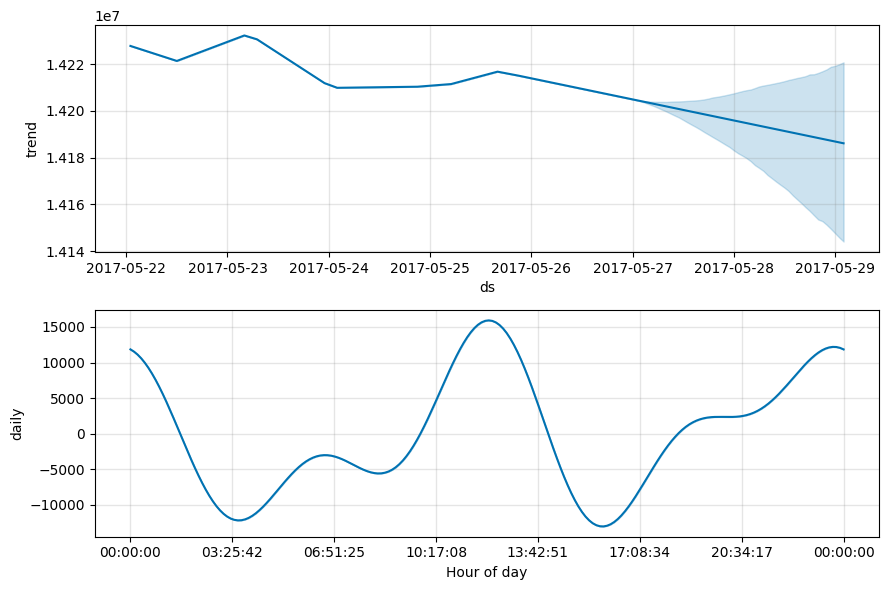

In [42]:
fig = model_base.plot_components(forecast_base)

From the visualization above, we can get insights such as:

- The trend shows that the `P-TPT` pressure is decreasing from time to time.
- The daily seasonality shows that pressure at 00 and 12 am always higher then the other hours.

## Trend and Seasonality Adjustment

### Trend Component

The trend components of our model, as plotted using `.plot_components()` method is producing a decreasing trend over the year. Trend is defined as a long term movement of average over the year. The methods that is implemented by Prophet is by default a **linear model** as shown below:

The trend component in a time series analysis shows the long-term movement in the data. From the visualization above, we can see the trend component of the sales data over time for P-TPT. We can observe if the trend is increasing, decreasing, or staying constant. 

Overall, the specific recommendations will depend on the root cause of the trend and the nature of the business. It is important to conduct a thorough analysis to identify the underlying factors and develop targeted strategies to address them.

**[OPTIONAL] - Mathematics Behind Trend**

The linear model will take a straight line across the x axis using the ordinary least square method, means it tries to produce the least difference between the line and the actual demand value resulting in the long-term “average” value given a time point t accross the date. Linear model or linear regression is a common statistical tool to model a numerical value. The formula of a linear regression is as follow:

$$y=mx+C$$

In our time series context, where we try to model our trend component, y equals to the Trend, m equals the difference for every change of time point and C for the intercept. In a more specific manner we could say that:

$$T(date)=m(date)+C$$

To illustrate the slope part of our trend which is an important part in understanding the trend, we can create the model using `ols()` function from `statsmodels` library like follow:

In [43]:
# %pip install statsmodels
# import the library
import statsmodels.api as sm

# define predictor and target variable
petro_copy = petro.copy()
petro_copy['date_ordinal'] = petro_copy['timestamp'].apply(lambda date: date.toordinal())

X = petro_copy['date_ordinal']
y = petro_copy['P-TPT']

# build ols model
X_train_sm = sm.add_constant(X)
lr = sm.OLS(y, X_train_sm).fit()

# printing the parameters
lr.params

const          2,734,803,756.72
date_ordinal          -3,694.08
dtype: float64

The coefficients of this model will be translated into:

$$pressure.in.TPT = −3,694.08 time + 2,734,803,756.72$$

The first one is our slope or m, which is calculated to be −3,694.08, so every increase of 1 unit of time, (in this case seconds), the pressure value decreases by 3,694.08. This shows a negative relationship between times and pressure and lead us to believe that there is indeed a downward trend for our pressure time series. 

### Automatic Changepoint Detection

In time series analysis, changepoints represent points in the data where the underlying trend or pattern changes. It is important to identify changepoints because they can have significant impacts on forecasting accuracy. Prophet implements a changepoint detection algorithm which helps to automatically identify the points where the slope of the trend changes. 

Automatic changepoint detection in Prophet can be a useful tool for data analysts and forecasters who want to build accurate and robust models of time-series data, without having to manually specify or identify changepoints.

By default, Prophet sets 25 potential changepoints (`n_changepoints=25`) which are uniformly placed on the first 80% of the time series (`changepoint_range=0.8`). This means that Prophet will look for up to 25 possible changepoints within the first 80% of the data to help identify where the trend may have changed. 

Adjusting the number of potential changepoints and the range where they are searched can affect the model's ability to capture trend changes in the data. Too few potential changepoints may cause the model to miss important changes, while too many potential changepoints may overfit the data and create too many small segments. Therefore, it's important to adjust these parameters appropriately to achieve the best model fit and forecasting accuracy.

**How Automatic Changepoint Works**

The automatic changepoint detection feature in Prophet works by searching for points in the time-series data where the underlying structure changes. These changes can manifest as shifts in trends, seasonality, or other patterns in the data. The algorithm in Prophet identifies these changepoints by fitting piecewise linear regressions to the data, where each piece corresponds to a different segment of the time-series with a distinct structure.

The algorithm first starts with an initial set of potential changepoints and then fits the piecewise linear regressions to the data, using a Markov chain Monte Carlo (MCMC) sampling approach to estimate the posterior distribution of the model parameters. The algorithm then evaluates the goodness-of-fit of the model using various metrics, such as the Bayesian information criterion (BIC), and determines whether a new changepoint should be added or an existing one should be removed.

This process continues iteratively until the algorithm finds the set of changepoints that provides the best fit to the data. The resulting changepoints can then be used to adjust the model accordingly, such as by incorporating additional terms to account for changes in the underlying structure of the data over time.

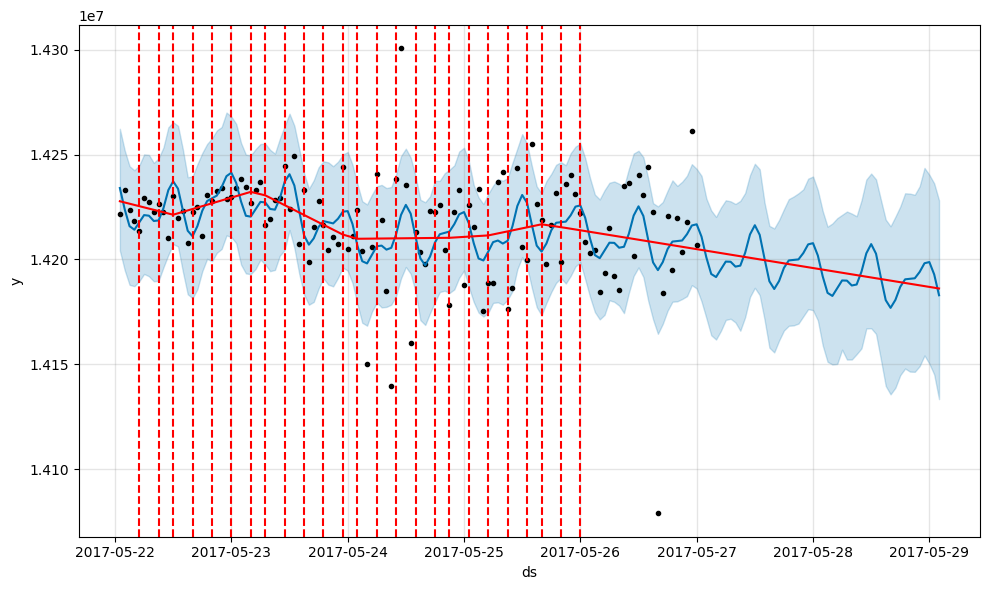

In [44]:
# for illustration purposes only, threshold = 0
from prophet.plot import add_changepoints_to_plot
fig = model_base.plot(forecast_base)
a = add_changepoints_to_plot(fig.gca(), model_base, forecast_base, threshold=0)

From the 25 potential changepoints, it will then calculate the magnitude of the slope change rate and decided the **significant** change rate. The model detected **25 significant changepoints** and separate the series into **26 different trend slopes**.

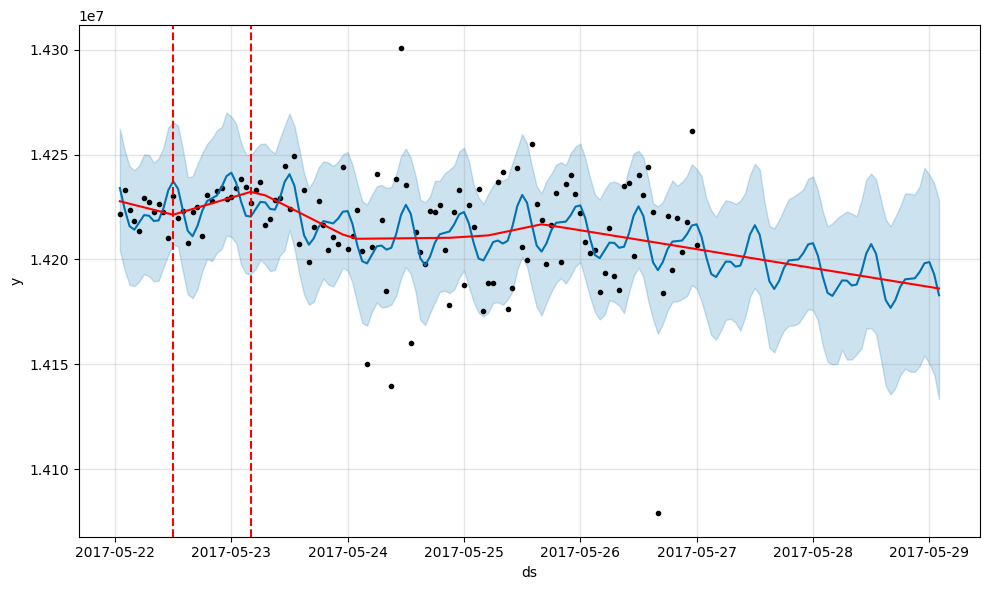

In [45]:
fig = model_base.plot(forecast_base)
a = add_changepoints_to_plot(fig.gca(), model_base, forecast_base)

### Adjusting Trend Flexibility

There are some parameters that we can use to adjust changepoint thus increase the flexibility of our trend. The parameter recommended to be tuned is:

- `changepoint_prior_scale` (default = 0.05): The flexibility of the trend, and in particular how much the trend changes at the trend changepoints. Recommended range: [0.001, 0.5]

💡 Increasing the default value of the parameter above will give extra flexibility to the trend line (overfitting the training data). On the other hand, decreasing the value will cause the trend to be less flexible (underfitting).

In [46]:
p_tpt.head() 

,ds,y,type
0,2017-05-22 01:00:00,"14,221,467.86",train
1,2017-05-22 02:00:00,"14,233,137.36",train
2,2017-05-22 03:00:00,"14,223,380.27",train
3,2017-05-22 04:00:00,"14,218,446.47",train
4,2017-05-22 05:00:00,"14,213,509.25",train


17:40:38 - cmdstanpy - INFO - Chain [1] start processing
17:40:38 - cmdstanpy - INFO - Chain [1] done processing


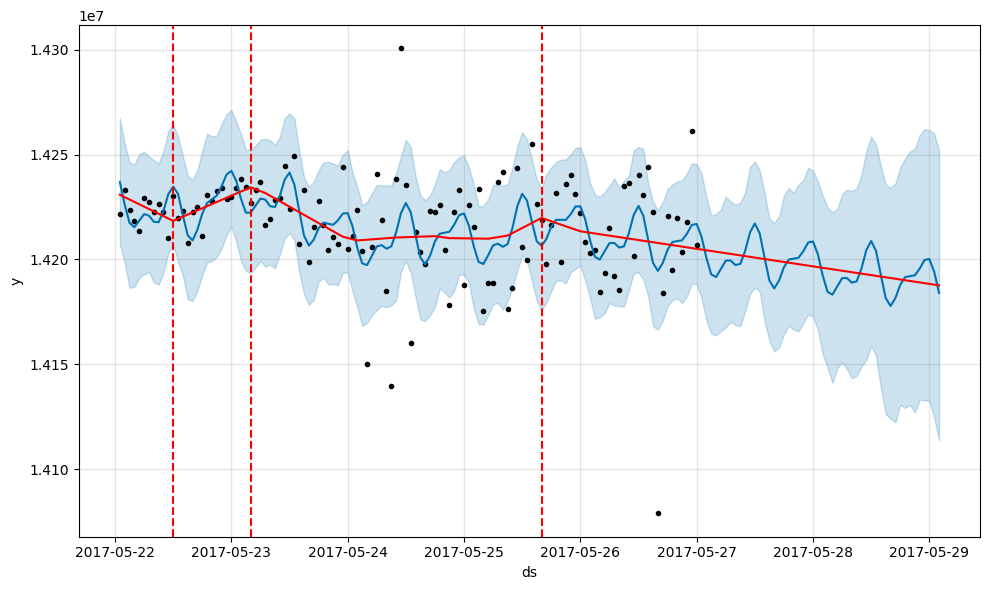

In [57]:
# build tuning_trend model
model_tuning_trend = Prophet(
    changepoint_prior_scale = 0.1 # default = 0.05
)

# train model 
model_tuning_trend.fit(train)

# forecasting
future_tuning_trend = model_tuning_trend.make_future_dataframe(periods = 50, freq= 'h')
forecast_tuning_trend = model_tuning_trend.predict(future_base)

# visualize
fig = model_tuning_trend.plot(forecast_tuning_trend)
a = add_changepoints_to_plot(fig.gca(), model_tuning_trend, forecast_tuning_trend)

Tuning the changepoint range and prior scale hyperparameters in the model can have a significant impact on the model's predictions. 

Setting the `changepoint_prior_scale` to 0.1, which is larger than the default value of 0.05, means that the model will be more flexible in detecting changepoints. This may help the model capture more complex patterns in the data, but it may also lead to overfitting.

Other than the one above, there are also other parameters provided:
- `changepoint_range` (default = 0.8): Proportion of the history in which the trend is allowed to change. Setting this parameter to 0.8 means that the changepoints will be distributed over the first 80% of the time series. **Not often tuned**. Can be tuned according to the data pattern, if newer data have similar pattern as older data, a number of 0.8 to 0.95 can be used.
- `n_changepoints` (default = 25): The number of first potential changepoints, **not recommended to be tuned**. This is better tuned by adjusting the regularization (`changepoint_prior_scale`)

While the `n_changepoints` is not recommended to be tuned, there are certain conditions which can make us change the value. If our dataset consists of a small number of observations, such as 5 years of monthly data (resulting in a total of only 60 data points), it becomes necessary to reduce the value of `n_changepoints`.

The chosen number should be sufficiently low to ensure that fragments of our dataset between changepoints effectively capture the underlying trend. For instance, if we observe a discernible trend in our data over the course of a year, setting the `n_changepoints` parameter to 4 or 5 may be appropriate. It’s important to note that this is just a rough example and the optimal value may vary depending on the specific characteristics of the dataset.

After tuning the model with these hyperparameters, we can expect to see different trend components in the visualization, as well as potentially different forecasts. The model may also perform better or worse on new data, depending on the nature of the time series and the quality of the tuning.

### Seasonality Component

Let’s talk about other time series component, seasonality. Seasonality in time series refers to a pattern that repeats at regular intervals, such as **daily**, **weekly, monthly**, or **yearly**. It is a predictable variation in the data that can be due to a number of factors, such as weather, holidays, and other cyclical events.

Checking the seasonality component in a time series analysis is important because it can help identify these patterns and allow for better forecasting. By understanding the seasonal patterns in the data, we can develop a more accurate forecast for future periods. In addition, identifying seasonal patterns can help us understand the underlying factors that influence the data and make more informed decisions. For example, if we observe a seasonal increase in sales during the holiday season, we may want to adjust our inventory or marketing strategies accordingly. 

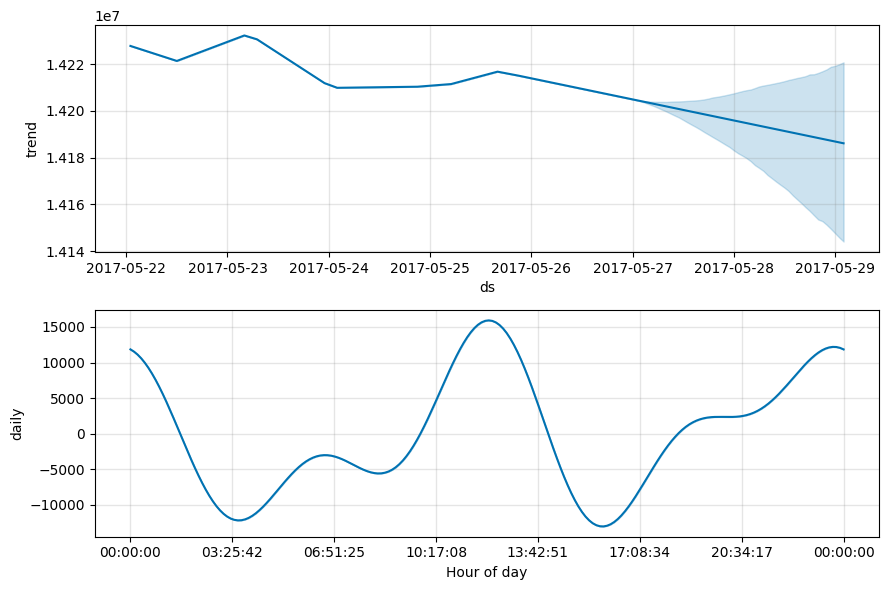

In [58]:
fig = model_base.plot_components(forecast_base)

from that visual The `prophet_model` function generates a visualization of the individual components of the time series: **trend** and **daily seasonality**

- The **trend** component shows the overall direction of the time series. 
- The **daily seasonality** component shows the patterns that repeat on a daikly basis.

By default, Prophet will try to determine existing seasonality based on existing data provided. In our case, the data provided is a **hourly** data from `2017-05-22 01:00:00` to `2017-05-29 02:00:00` .

- Any hourly data by default will be detected to have a **daily seasonality**.
- Any daily sampled data by default will be detected to have a **weekly seasonality**.
- While **yearly seasonality**, by default will be set as `True` if the provided data has more than 2 years of daily sample. Since our data does not accommodate 2 years data, by default the yearly seasonality will be set as `False`.

By examining the seasonality components, we can gain insights into the periodic patterns that occur in the data. *For example*, we can identify which months or days of the week have higher or lower sales, and use this information to make informed business decisions. We can also identify whether the patterns are changing over time, which can help us adjust our strategies accordingly.

In the visualization, each component is shown separately, with the actual data points overlaid on top of the predicted values. This allows us to see how well the model is capturing the patterns in the data.

### Fourier Order

Prophet uses a Fourier series to approximate the seasonality effect. It is a way of approximating a periodic function as a (possibly infinite) **sum of sine and cosine** functions. 

💡 The number of terms in the partial sum (the order) is a parameter that determines how quickly the seasonality can change. Increasing the fourier order will give extra flexibility to the seasonality (overfitting the training data), and vice versa.

Here is an interactive introduction to Fourier: http://www.jezzamon.com/fourier/

### Custom Seasonalities

The default provided seasonality modelled by Prophet for a daily sampled data is: weekly and yearly. 

Consider this case: a record in Petrobas records hourly per-shift (five hours), to identify the shift as seasonality we will need to define a non-regular seasonality. There are two steps we have to do:
1. Remove default seasonality (eg: remove weekly and yearly seasonality) by setting `False`
2. Add seasonality (eg: add shift seasonality) by using `.add_seasonality()` method before fitting the model

We ended up with formula:
$yhat(t) = T(t) + S_{daily}(t)+ \bf{S_{shift}(t)}$

17:54:09 - cmdstanpy - INFO - Chain [1] start processing
17:54:09 - cmdstanpy - INFO - Chain [1] done processing


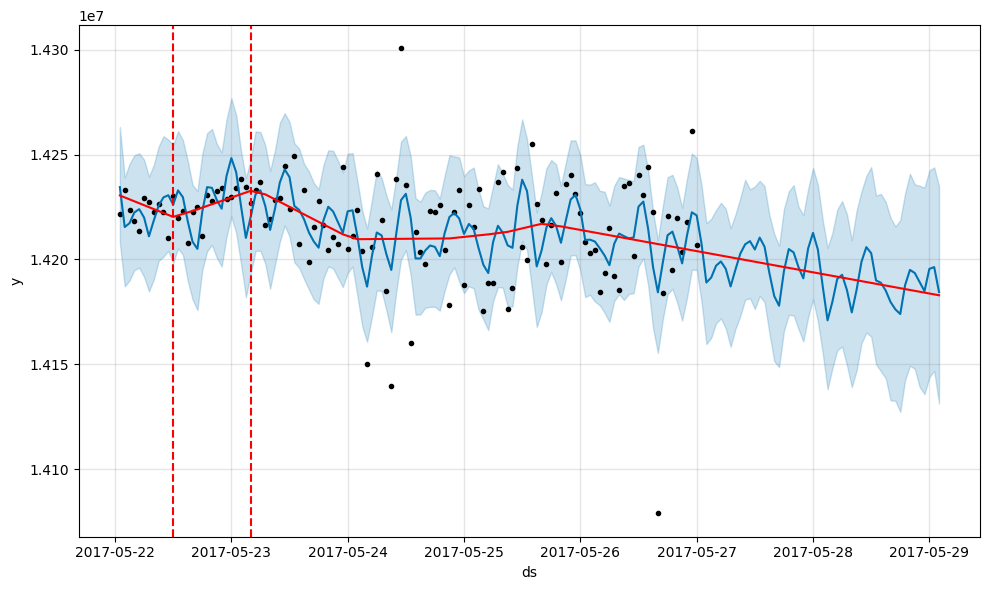

In [61]:
# build model
model_custom_seasonality = Prophet(weekly_seasonality=False, yearly_seasonality=False)

# add seasonality [shift = 5 hours Operational time]
model_custom_seasonality.add_seasonality(name = 'shift',
                            period = 5/24, # define the time 5 hours (default daily)
                            fourier_order = 3)



# train model 
model_custom_seasonality.fit(train)

# forecasting
future_custom_seasonality = model_custom_seasonality.make_future_dataframe(periods = 50, freq= 's')
forecast_custom_seasonality = model_custom_seasonality.predict(future_base)

# visualize
fig = model_custom_seasonality.plot(forecast_custom_seasonality)
a = add_changepoints_to_plot(fig.gca(), model_custom_seasonality, forecast_custom_seasonality)

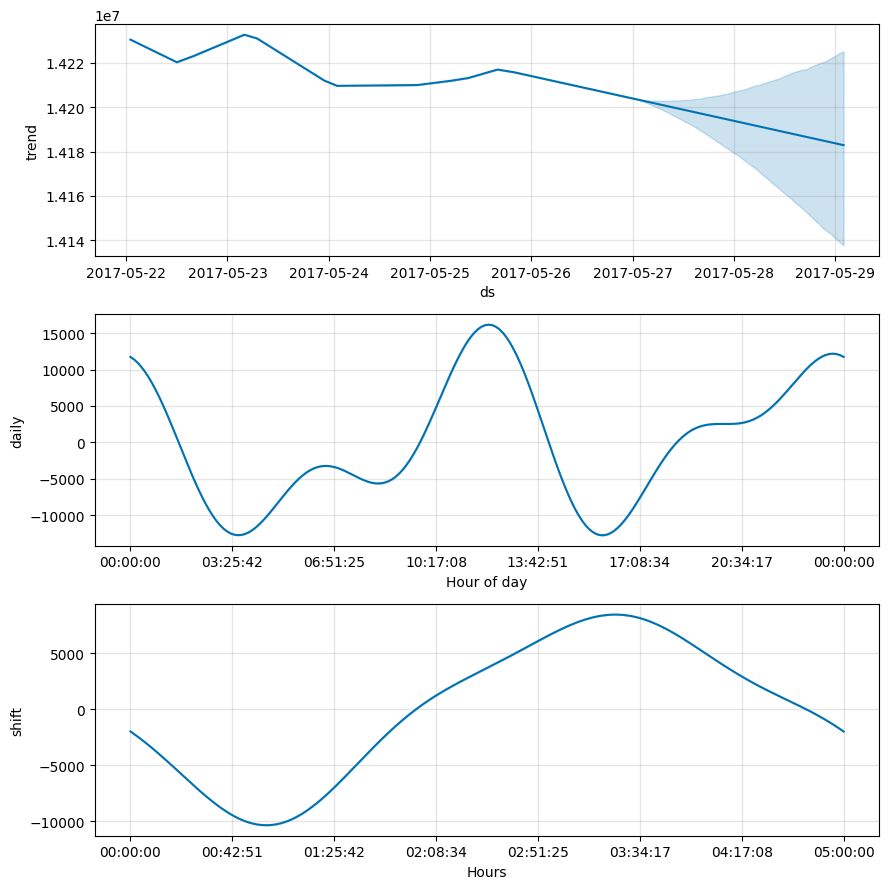

In [62]:
fig = model_custom_seasonality.plot_components(forecast_custom_seasonality)

In [64]:
forecast_custom_seasonality['trend']+forecast_custom_seasonality['daily']+forecast_custom_seasonality['shift']

0     14,234,453.17
1     14,215,430.10
2     14,217,287.61
3     14,222,428.83
4     14,223,939.98
           ...     
165   14,189,215.18
166   14,184,862.37
167   14,195,476.87
168   14,196,333.70
169   14,184,394.85
Length: 170, dtype: float64

In [65]:
forecast_custom_seasonality['yhat']

0     14,234,453.17
1     14,215,430.10
2     14,217,287.61
3     14,222,428.83
4     14,223,939.98
           ...     
165   14,189,215.18
166   14,184,862.37
167   14,195,476.87
168   14,196,333.70
169   14,184,394.85
Name: yhat, Length: 170, dtype: float64

### [Holiday Effects](https://facebook.github.io/prophet/docs/seasonality,_holiday_effects,_and_regressors.html#modeling-holidays-and-special-events)

Prophet offers the benefit of incorporating a holiday effect into the time series model. The holiday effect refers to non-regular events that may have a significant impact on the time series, such as **national holidays**, **major sporting events**, or **sales promotions**. 

Unlike regular seasonality patterns that are often automatically detected, the holiday effect needs to be **manually** specified by the user. By including the holiday effect in the model, Prophet can provide more **accurate** forecasts and **better capture** the effects of these important events on the time series.


In Prophet, we can specify holidays by creating a dataframe that includes the **dates** and **names of the holidays**. The dataframe should have two columns: `holiday` and `ds`, where `holiday` contains the name of the holiday and `ds` contains the date. 

In addition we can add `lower_window` and `upper_window` parameters are used to expand the holiday effect to include a range of days around the holiday. By default, both parameters are set to 0, which means that only the exact holiday dates are included in the holiday effect. 

Whether to set the `lower_window` and `upper_window` parameters depends on the specific context of the analysis and the domain knowledge of the user. If there are reasons to believe that the holiday effect may extend beyond the exact holiday dates, it may be appropriate to increase the values of `lower_window` and `upper_window` to capture this effect. 

However, it's also possible that the holiday effect is only present on the exact holiday dates and not on surrounding days, in which case it's appropriate to leave both parameters at their default value of 0. Ultimately, the decision whether to set `lower_window` and `upper_window` should be made based on the specific characteristics of the time series being analyzed and the domain knowledge of the user.

In this case, we'll prepare a `holidays` data frame with the following column:

- `holiday`: the holiday unique name identifier
- `ds`: timestamp
- `lower_window`: how many time unit **behind** the holiday that is assumed to to be affected (smaller or equal than zero)
- `upper_window`: how many time unit **after** the holiday that is assumed to be affected (larger or equal to zero)

⚠️ It must include all occurrences of the holiday, both in the **past** (back as far as the historical data go) and in the **future** (out as far as the forecast is being made).

In [45]:
holidays = pd.DataFrame({
    'holiday': 'new_year_eve',
    'ds': pd.to_datetime(['2013-12-31', '2014-12-31', # past date, historical data 
                          '2015-12-31']), # future date, to be forecasted
    'lower_window': -4, # include 27th - 31st December
    'upper_window': 0})
holidays

,holiday,ds,lower_window,upper_window
0,new_year_eve,2013-12-31,-4,0
1,new_year_eve,2014-12-31,-4,0
2,new_year_eve,2015-12-31,-4,0


### Modeling Holidays and Special Events

to add holidays and special events in prophet model, we can use the `holiday` parameter. Because our data does not have seasonal and is not really influenced by holidays, here is an example code to add holidays if your data has a certain seasonal.

In [ ]:
# # fitting model
# model_holiday = Prophet(holidays = holidays)
# model_holiday.fit(train)

# # forecasting
# future = model_holiday.make_future_dataframe(periods = 31251, freq= 's')
# forecast = model_holiday.predict(future)

# # visualize
# fig = model_holiday.plot(forecast)

If our data has seasonal and we plot the components, we could also get the holiday components listed as one of the time series components like this example:

![seasonality.png](assets/holiday.png)

### [[OPTIONAL] Built-in Country Holidays](https://facebook.github.io/prophet/docs/seasonality,_holiday_effects,_and_regressors.html#built-in-country-holidays)


Prophet has a **built-in** collection of country-specific holidays, which can be easily incorporated into the model using the `.add_country_holidays()` method. This feature is useful for modeling time series data that are impacted by country-specific holidays, such as **national holidays** or **cultural events**. 

Using built-in country holidays can significantly **improve** the accuracy of our model in predicting time series data that are influenced by such events, and can save us the time and effort of manually specifying these holidays ourselves.

For instance, we can use the `country_name` parameter to specify the country whose holidays we want to include in our model. For example, to include holidays for Indonesia, we can set `country_name='ID'` when calling `.add_country_holidays()`. The holidays will then be automatically added to our model and taken into account when making forecasts.

In [ ]:
# model_holiday_indo = Prophet()
# model_holiday_indo.add_country_holidays(country_name='BR') 
# model_holiday_indo.fit(p_tpt)

# model_holiday_indo.train_holiday_names

💡 We can also use the `make_holidays` module in Prophet allows us to manually populate holiday dates for a specific country. This is useful if we want to include only certain holidays that are not covered by the built-in country holidays or to remove certain holidays that are not relevant for our analysis. 

For example we will generate a list of Indonesian holidays for the years 2020 and 2021 using the `make_holidays_df` function from Prophet. We will need 2 parameters:

- `year_list`: list of year that we want to generate
- `country`: country code that can be seen from [this reference](https://en.wikipedia.org/wiki/ISO_3166-1_alpha-2)

In [63]:
from prophet.make_holidays import make_holidays_df

id_holidays = make_holidays_df(
    year_list=[2024,2025], country='ID'
)
id_holidays.head(n=10)

,ds,holiday
0,2024-01-01,New Year's Day
1,2024-02-10,Lunar New Year (estimated)
2,2024-03-11,Day of Silence
3,2024-03-29,Good Friday
4,2024-05-22,Buddha's Birthday (estimated)
5,2024-05-01,International Labor Day
6,2024-05-09,Ascension Day
7,2024-06-01,Pancasila Day
8,2024-08-17,Independence Day
9,2024-12-25,Christmas Day


That code is useful when we want to manually specify certain holidays to be included in our Prophet model, rather than using the built-in country-specific holidays.

## Forecasting Evaluation

Recall how we performed a visual analysis on how the performance of our forecasting model earlier. The technique was in fact, a widely used technique for model cross-validation. It involves splitting our data into two parts:

- Train data is used to train our time series model in order to acquire the underlying patterns such as trend and seasonality.
- Test data is purposely being kept for us to perform a cross-validation and see how our model perform on an **unseen data**.

The objective is quite clear, is that we are able to acquire a glimpse of what kind of error are we going to expect for the model.

### Evaluation Metrics

Based on the plot above, we can see that the model is capable in forecasting the actual future value. But for most part, we will need to quantify the error to be able to have a conclusive result. To quantify an error, we need to calculate the **difference between actual demand and the forecasted demand**. However, there are several metrics we can use to express the value. Some of them are:

- Mean Absolute Error (MAE)

<center>

$$MAE = \frac{\sum_{i=1}^{n}\left | y_{pred, i} - y_{real, i} \right |}{n}$$

</center>

- Mean Percentage Absoulute Error (MAPE)

<center>

$MAPE = \frac{1}{n}\Sigma{\frac{| y-\hat y|}{y}} \times 100\%$  

</center>

Each of the metrics above are commonly used in evaluating forecasting model. The idea of choosing the error metrics is by understanding what is being quantified. Any of the metrics can be used to benchmark a forecasting model, as long as we are consistent in using it. The summary of the 2 metrics is listed as follow:

- **Mean Absolute Error (MAE)**, is a statistical metric that quantifies the average difference between the actual and predicted values in a set of data, disergarding the direction of the difference. A lower MAE indicates better prediction, as it signifies that the model's predictions are closer to the true values on average. It is important to consider the scale and context of the problem when interpreting the MAE since MAE values affected by the scale of the target.

- **Mean Percentage Absoulute Error (MAPE)**, it gives the average percentage over the actual value range, making it more interpretable and comparable across different datasets or variables with varying scales. A lower MAPE indicates a higher level of accuracy, implying that the model's predictions closely align with the true values.


In this course, we are going to use MAPE for better interpretability. However, do note one of the downside in using MAPE is that it requires no zero value since the formula needs to divide the error using its actual value. Since our data has no 0 value in the series, we will proceed to calculate the error. The MAPE is often used in practice because of its very intuitive interpretationin terms of relative error.  The use of the MAPE is relevant in finance, for instance,as gains and losses are often measured in relative values. To acquire the error, we will need to subtract the actual value within `test` data frame using the forecasted value stored under `yhat` column in `forecast_final` data frame:

In [66]:
from sklearn.metrics import mean_absolute_percentage_error

# forecast final on data train
forecast_final = forecast_custom_seasonality[forecast_custom_seasonality['ds'] <= '2017-05-27']

# MAPE train
train_mape = mean_absolute_percentage_error(y_true = train['y'],
                                            y_pred = forecast_final['yhat'])
train_mape*100  

0.11346897123775564

In [67]:
# forcast final on data test
forecast_test = forecast_custom_seasonality[forecast_custom_seasonality['ds']  > '2017-05-27']

# MAPE test
test_mape = mean_absolute_percentage_error(y_true = test['y'],
                                            y_pred = forecast_test['yhat'])
test_mape*100  

0.1094174735096861

Based on the evaluation results of the model with custom seasonality based on the 5-hour machine shift pattern, the MAPE on the train data is 0.1134% and on the test data is 0.1094%. MAPE values that are less than 10% indicate a very high level of accuracy. this can also be indicated as an *overfitting* condition, which is a model that is too good at predicting training data so that it is feared that there will be bias when used to forecast future data.